# GAM

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [2]:
from morai.experience import charters, experience, tables
from morai.forecast import metrics, preprocessors
from morai.models import core, r
from morai.utils import custom_logger, helpers

In [3]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

## Model

A GAM can be thought of as an extension of a GLM. The both use a logistic regression. One of the differences is that a GAM uses functions instead of coefficients that are penalized.

<center>GLM</center>
$$
n = \beta_0 + \beta_i x_i
$$

<center>GAM</center>
$$
n = \beta_0 + f_i(x_i)
$$

A GAM can be a GLM when the effective degree of freedom are 1 and when the coefficient is linear.

In [143]:
import importlib

importlib.reload(r)

<module 'morai.models.r' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\models\\r.py'>

In [144]:
from morai.integrations import hmd

db_filepath = r"files/integrations/hmd/hmd.sql"
hmd_usa_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name="hmd")
hmd_usa_df = hmd_usa_df[(hmd_usa_df["year"] >= 1950) & (hmd_usa_df["year"] <= 2023)]
hmd_usa_df["qx_raw"] = hmd_usa_df["total_death"] / hmd_usa_df["total_exposure"]

In [145]:
preprocess_dict = preprocessors.preprocess_data(
    hmd_usa_df,
    feature_dict={
        "target": ["qx_raw"],
        "weight": ["total_exposure"],
        "passthrough": [
            "year",
            "age",
        ],
    },
    standardize=True,
    add_constant=True,
)

X = preprocess_dict["X"]
y = preprocess_dict["y"]
md_encoded = preprocess_dict["md_encoded"]
weights = preprocess_dict["weights"]
mapping = preprocess_dict["mapping"]

 2026-01-03 09:41:31 | morai.forecast.preprocessors | INFO     | model target: ['qx_raw'] 
 2026-01-03 09:41:31 | morai.forecast.preprocessors | INFO     | model weights: ['total_exposure'] 
 2026-01-03 09:41:31 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2026-01-03 09:41:31 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['year', 'age', 'constant'] 
 2026-01-03 09:41:32 | morai.forecast.preprocessors | INFO     | standardizing the features with StandardScaler 


In [146]:
GAMR = r.GAMR()
spline_dict = {
    "age": {"df": 10, "degree": 3, "bs": "ps"},
}
GAMR.setup_model(
    X=X,
    y=y,
    weights=weights,
    spline_dict=spline_dict,
    distribution="quasibinomial",
)

 2026-01-03 09:41:32 | morai.models.r | INFO     | setup GAM model with mgcv and `quasibinomial` distribution with `logit` link 
 2026-01-03 09:41:34 | morai.models.r | INFO     | formula: 
 2026-01-03 09:41:34 | morai.models.r | INFO     | > qx_raw ~ s(`age`, k=10, m=3, bs='ps')+`constant`+`year` 
 2026-01-03 09:41:34 | morai.models.r | INFO     | fitting the model: 
 2026-01-03 09:41:34 | morai.models.r | INFO     | > model <- bam(formula, data=data, weights=weights, family=family, drop.intercept=TRUE) 
 2026-01-03 09:41:35 | morai.models.r | INFO     | model fitted 


In [147]:
print(GAMR.summary(expand=True))

Generalized Additive Model (mgcv) Summary
Family                : quasibinomial
Link                  : logit
Number of Observations: 8214
Adjusted R-squared    : 0.988
Deviance Explained    : 99.4%
Scale Estimate        : 337.1
fREML                 : 3.562e+04

Formula:
qx_raw ~ s(`age`, k=10, m=3, bs='ps')+`constant`+`year`

Parametric Coefficients:
               coef   std err         z   P>|z|     [0.025     0.975]
constant  -4.411715  0.006570  -671.494  0.0000  -4.424592  -4.398838
year      -0.247504  0.001557  -159.009  0.0000  -0.250555  -0.244453

Smooth Terms:
             edf    Ref.df              F  p-value     alpha
s(age)  8.996918  8.999993  106820.213331      0.0  1.511197

Expanded Smooth Terms:
        name        coef
2   s(age).1  271.051672
3   s(age).2    2.923928
4   s(age).3   23.878575
5   s(age).4   21.071198
6   s(age).5   23.306164
7   s(age).6   24.614854
8   s(age).7   26.168798
9   s(age).8   28.620898
10  s(age).9   31.236613


In [148]:
GAMR.get_odds()

 2026-01-03 09:41:35 | morai.models.r | INFO     | generating odds ratio from model 


constant    0.012134
year        0.780747
Name: Estimate, dtype: float64

In [149]:
predictions = GAMR.predict(X)

hmd_usa_df = experience.calc_qx_exp_ae(
    model_data=hmd_usa_df,
    predictions=predictions,
    model_name="r",
    exposure_col="total_exposure",
    actual_col="total_death",
)

 2026-01-03 09:32:40 | morai.experience.charters | INFO     | The weights list is 1 long and should be 2 long. Using the first weight for all weights. 


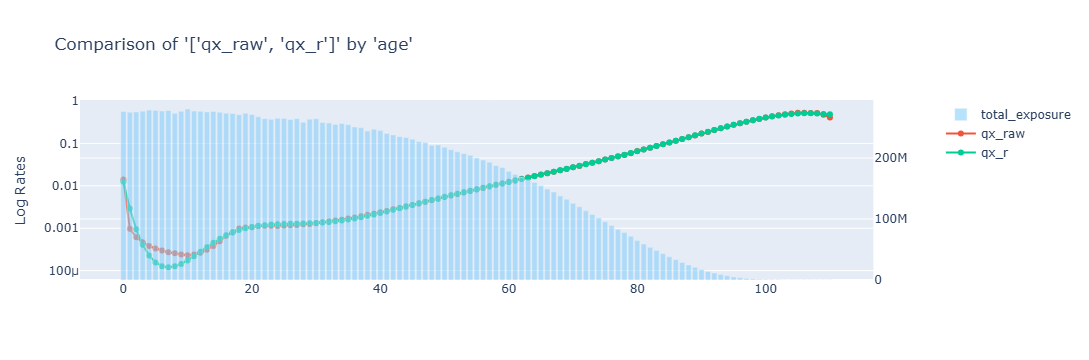

In [130]:
charters.compare_rates(
    hmd_usa_df,
    x_axis="age",
    rates=["qx_raw", "qx_r"],
    weights=["total_exposure"],
    secondary="total_exposure",
    y_log=True,
)

## Residual Analysis

In [75]:
residuals = pd.DataFrame(
    {
        "deviance": GAMR.ro("residuals(model, type='deviance')"),
        "pearson": GAMR.ro("residuals(model, type='pearson')"),
        "fitted": predictions,
    }
)

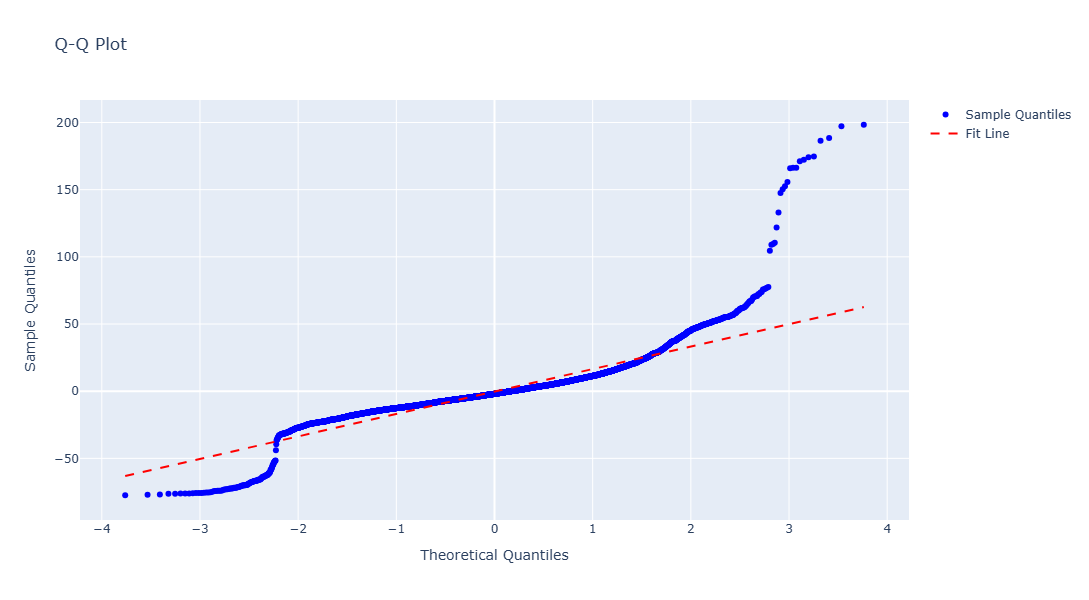

In [78]:
charters.qq(residuals["pearson"])

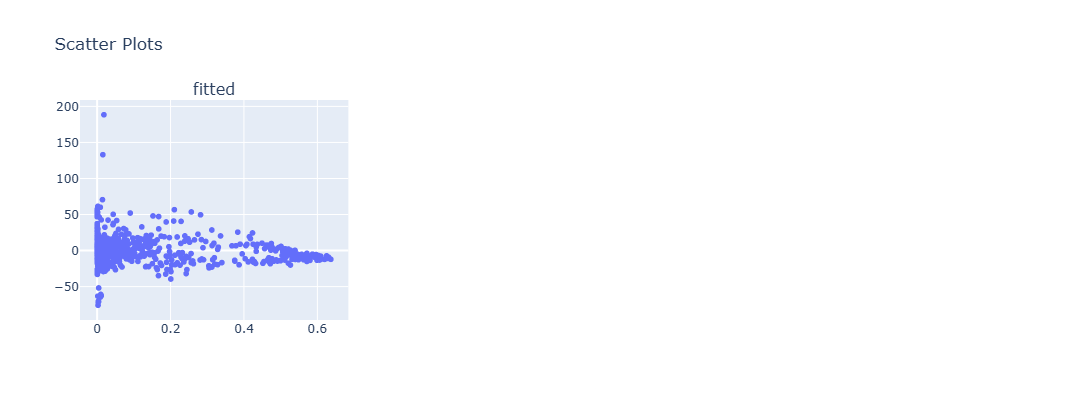

In [76]:
charters.scatter(
    residuals, target="pearson", features=["fitted"], sample_nbr=1000
)

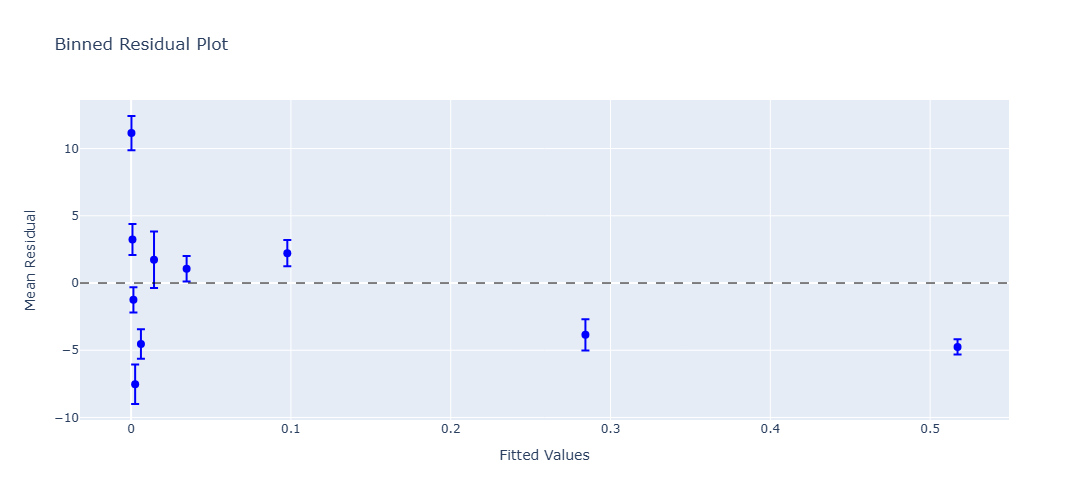

In [77]:
charters.residual_plot(
    fitted=residuals["fitted"], residuals=residuals["pearson"], n_bins=10
)

## Prediction Analysis

 2026-01-03 09:32:48 | morai.experience.charters | INFO     | Creating '4' target plots. 


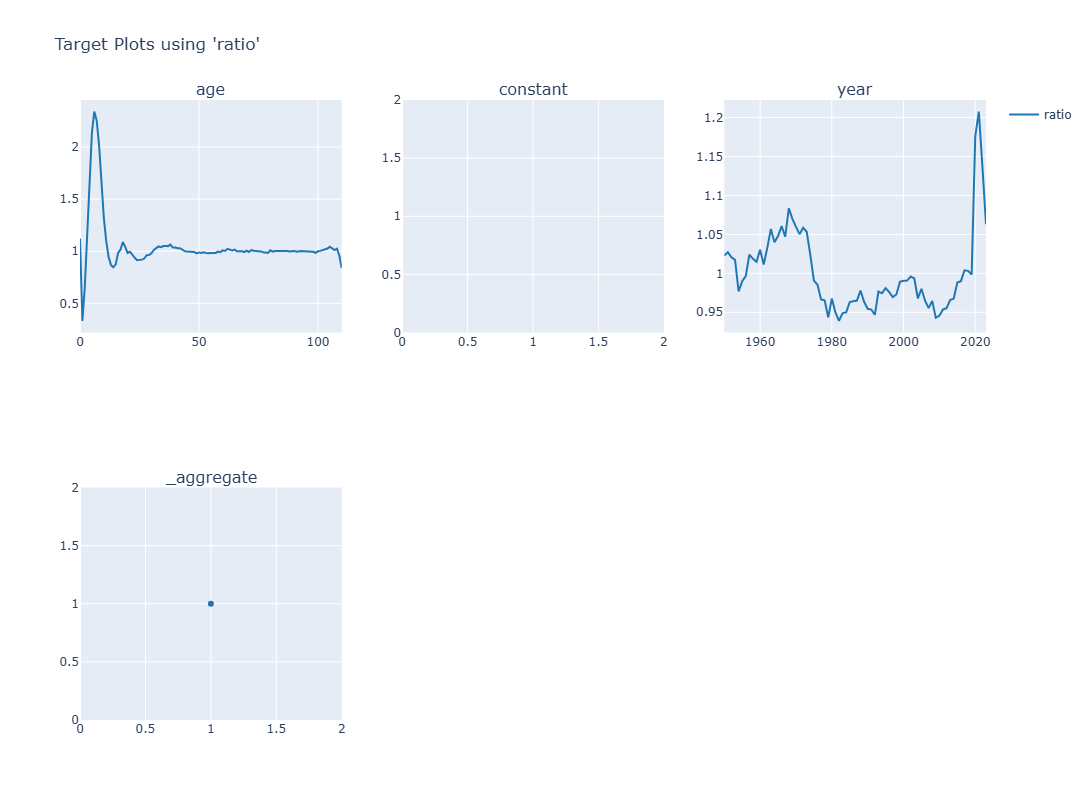

In [131]:
charters.target(
    df=hmd_usa_df,
    target="ratio",
    cols=3,
    features=X.columns,
    numerator=["total_death"],
    denominator=["exp_amt_r"],
).show()

 2026-01-03 09:32:49 | morai.experience.charters | INFO     | Model: [GAMR] for partial dependence plot. 
 2026-01-03 09:32:49 | morai.experience.charters | INFO     | Weights: [total_exposure] 
 2026-01-03 09:32:49 | morai.experience.charters | INFO     | x_axis: [year] type: [standardized] center: [global] 
 2026-01-03 09:32:49 | morai.experience.charters | INFO     | Creating 74 predictions. 


Processing:   0%|          | 0/74 [00:00<?, ?combo/s]

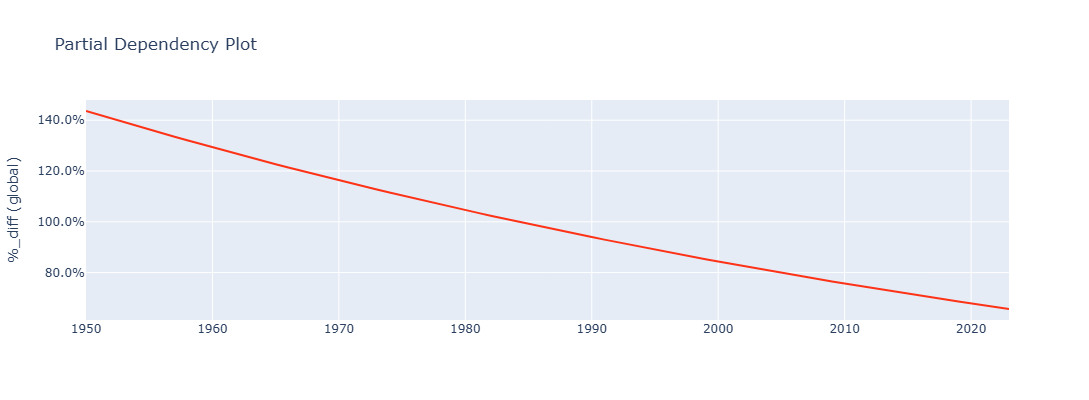

In [132]:
charters.pdp(
    model=GAMR,
    df=md_encoded,
    x_axis="year",
    weight="total_exposure",
    mapping=mapping,
    display=True,
)

# Other Models

Comparing the different implementations of GAM, **R(mgcv)** is the only one that is reliably providing output with accuracy and without error.
- R(mgcv)
  - Seems to be actively maintained and does not cause warnings.
  - The process does take longer as data gets copied into R environments
  - https://cran.r-project.org/web/packages/mgcv/
- statsmodels
  - This model does work when there are no weights.
  - However, when using weights the model does not provide the expected response. A user may be able to build out a weighted function where it splits out those weights manually.
  - Another option was to use failure/success in the model, however that seemed to create output errors.
  - https://www.statsmodels.org/stable/generated/statsmodels.gam.generalized_additive_model.GLMGam.html#
- pygam
  - pygam does seem to work, however it has more warnings, but is currently being updated
  - https://github.com/dswah/pyGAM

In [88]:
test_forecast_path = helpers.ROOT_PATH / "tests" / "files" / "forecast" / "models"
sigmoid_data = pd.read_csv("tests/files/forecast/models/sigmoid_data.csv")
feature_dict = {
    "target": ["rate"],
    "weight": ["weight"],
    "passthrough": ["age", "gender", "faceband"],
}
preprocess_dict = preprocessors.preprocess_data(
    sigmoid_data,
    feature_dict=feature_dict,
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]

 2026-01-02 00:29:37 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2026-01-02 00:29:37 | morai.forecast.preprocessors | INFO     | model weights: ['weight'] 
 2026-01-02 00:29:37 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2026-01-02 00:29:37 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['age', 'gender', 'faceband', 'constant'] 


## R(mgcv)

In [89]:
GAMR = r.GAMR()
spline_dict = {
    "age": {"df": 12, "degree": 3, "bs": "ps"},
}

In [90]:
GAMR.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict)

 2026-01-02 00:29:40 | morai.models.r | INFO     | setup GAM model with mgcv and `quasibinomial` distribution with `logit` link 
 2026-01-02 00:29:41 | morai.models.r | INFO     | formula: 
 2026-01-02 00:29:42 | morai.models.r | INFO     | > rate ~ s(`age`, k=12, m=3, bs='ps')+`constant`+`faceband`+`gender` 
 2026-01-02 00:29:42 | morai.models.r | INFO     | fitting the model: 
 2026-01-02 00:29:42 | morai.models.r | INFO     | > model <- bam(formula, data=data, weights=weights, family=family, drop.intercept=TRUE)` 
 2026-01-02 00:29:42 | morai.models.r | INFO     | model fitted 


In [91]:
print(GAMR.summary(expand=True))

Generalized Additive Model (mgcv) Summary
Family                : quasibinomial
Link                  : logit
Number of Observations: 480
Adjusted R-squared    : 0.998
Deviance Explained    : 99.5%
Scale Estimate        : 0.8419
fREML                 : 646.1

Formula:
rate ~ s(`age`, k=12, m=3, bs='ps')+`constant`+`faceband`+`gender`

Parametric Coefficients:
constant   -4.004392e+00
faceband    5.040397e+00
gender     -2.424741e-15

Smooth Terms:
             edf    Ref.df           F  p-value      alpha
s(age)  5.181695  5.847285  870.747807      0.0  44.384753

Expanded Smooth Terms:
         name       coef
3    s(age).1  -1.797458
4    s(age).2  -1.997472
5    s(age).3  -0.613487
6    s(age).4   2.037228
7    s(age).5   5.088429
8    s(age).6   8.306820
9    s(age).7  10.532351
10   s(age).8  11.034027
11   s(age).9  10.703045
12  s(age).10  10.069730
13  s(age).11   9.169025


In [92]:
predictions = GAMR.predict(X)
sigmoid_data["r"] = predictions

 2026-01-02 00:29:42 | morai.models.r | INFO     | predicted rates 


## Statsmodels

In [93]:
GAM = core.GAMStats()
spline_dict = {
    "age": {"df": 12, "degree": 3},
}
GAM.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict, alpha=0)
GAM.fit()

 2026-01-02 00:29:43 | morai.models.core | INFO     | setup GAM model with statsmodels and <class 'statsmodels.genmod.families.family.Binomial'> family... 
 2026-01-02 00:29:43 | morai.models.core | INFO     | created splines for `['age']` 
 2026-01-02 00:29:43 | morai.models.core | INFO     | fiting the model 
 2026-01-02 00:29:43 | morai.models.core | INFO     | `12` degrees of freedom for smoother with `11.55` being effective 


In [94]:
print(GAM.model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                  480
Model:                         GLMGam   Df Residuals:                  -234.92
Model Family:                Binomial   Df Model:                       713.92
Link Function:                  Logit   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:                -3040.4
Date:                Fri, 02 Jan 2026   Deviance:                       1177.1
Time:                        00:29:43   Pearson chi2:                     790.
No. Iterations:                    11   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
constant      -8.7990      9.664     -0.910      0.3

In [95]:
predictions = GAM.predict(X)
sigmoid_data["sm"] = predictions

## Pygam

In [96]:
GAMPy = core.GAMPy()

In [97]:
spline_dict = {
    "age": {"df": 12, "degree": 3},
}
GAMPy.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict, alpha=0)

 2026-01-02 00:29:45 | morai.models.core | INFO     | setup GAM model with pygam and `binomial` distribution with `logit` link 


GAM(callbacks=['deviance', 'diffs'], distribution='binomial', 
   fit_intercept=False, lam=0, link='logit', max_iter=100, 
   terms=s(0) + l(1) + l(2) + l(3), tol=0.0001, verbose=False)

In [98]:
GAMPy.fit()

 2026-01-02 00:29:46 | morai.models.core | INFO     | fiting the model 


C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\pygam\pygam.py:1150: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\pygam\pygam.py:1151: RuntimeWarning:

invalid value encountered in scalar divide



GAM(callbacks=[Deviance(), Diffs()], 
   distribution=BinomialDist(levels=1), fit_intercept=False, 
   link=LogitLink(), max_iter=100, terms=s(0) + l(1) + l(2) + l(3), 
   tol=0.0001, verbose=False)

In [99]:
GAMPy.model.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                        14.0
Link Function:                        LogitLink Log Likelihood:                                       -inf
Number of Samples:                          480 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.3273
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.9958
Feature Function                  Lam

C:\Users\johnk\AppData\Local\Temp\ipykernel_23188\1557638170.py:1: UserWarning:

KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 




In [100]:
predictions = GAMPy.predict(X)
sigmoid_data["pygam"] = predictions

## Compare

 2026-01-02 00:29:49 | morai.experience.charters | INFO     | The weights list is 1 long and should be 4 long. Using the first weight for all weights. 


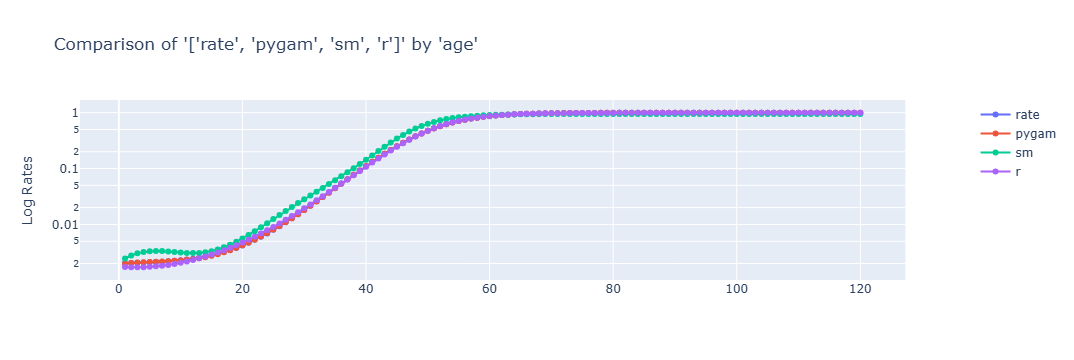

In [101]:
charters.compare_rates(
    df=sigmoid_data,
    x_axis="age",
    rates=["rate", "pygam", "sm", "r"],
    weights=["weight"],
    display=True,
    y_log=True,
)

# Test

In [25]:
import importlib

importlib.reload(core)

<module 'morai.models.gam' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\models\\gam.py'>